
# Universitat Oberta de Catalunya  
## Grado en Ingeniería Informática  
### Trabajo Final de Grado (TFG)

---

## Sistema de recomendaciones basado en técnicas de aprendizaje automático para ampliar la exploración de géneros musicales 
**Autor:** Marc Fernández Pereira  
**Bajo supervisión de:** Dra. María Moreno de Castro  
**Área:** Inteligencia Artificial  
**Semestre:** Otoño 2025  



---

## Índice



In [24]:
# Este import centraliza todas las librerías estándar, scikit-learn y funciones personalizadas
from imports import *

### Funciones

In [25]:
# Paleta fija con colores diferenciados (hasta 10 clústeres).
palette_colors = [
    '#1f77b4',  # azul
    '#ff7f0e',  # naranja
    '#2ca02c',  # verde
    '#d62728',  # rojo
    '#9467bd',  # morado
    '#8c564b',  # marrón
    '#17becf',  # cian
    '#7f7f7f',  # gris
    '#bcbd22',  # oliva
    '#000000'   # negro
]


def cluster_silhouette_score(model, X, sample_size=10000):
    """
    Calcula el coeficiente de Silhouette como métrica de validación interna para clustering.
    Adaptada para su uso con permutation_importance de scikit-learn.
    
    :param model: Modelo de clustering entrenado (KMeans, GMM, etc.)
    :param X: Matriz de características (n_samples, n_features)
    :param sample_size: Tamaño de muestra para reducir coste computacional (por defecto 10000)
    :return: Coeficiente de Silhouette (valores entre -1 y 1)
    """
    labels = model.predict(X)
    return silhouette_score(X, labels, sample_size=sample_size, random_state=42)



### Carga de datos y modelos entrenados en el cuaderno de clustering


In [26]:
# Cargar dataset preprocesado
df = pd.read_csv('spotify_tracks_clean.csv')

# Cargar scaler y PCA
scaler = joblib.load('scaler_object.pkl')
pca = joblib.load('models/pca_95var.pkl')

# Variables utilizadas en el modelado de clustering
selected_vars = ['energy', 'acousticness', 'danceability', 'valence', 'tempo', 'liveness']

# Matriz de características original
X = df[selected_vars].copy()

# Datos estandarizados (mismas variables que en el cuaderno de modelado)
df_scaled = pd.DataFrame(
    scaler.transform(X),
    columns=[f"{col}_norm" for col in selected_vars]
)

# Proyección PCA (mismas componentes que en el cuaderno de modelado)
X_pca = pca.transform(df_scaled)
X_pca_df = pd.DataFrame(
    X_pca,
    columns=[f"PC{i+1}" for i in range(X_pca.shape[1])]
)

# Cargar modelos de clustering
kmeans_k7_estand = joblib.load('models/kmeans_k7_estand.pkl')
kmeans_k4_pca = joblib.load('models/kmeans_k4_pca.pkl')
kmeans_k7_pca = joblib.load('models/kmeans_k7_pca.pkl')
gmm_n20_pca = joblib.load('models/gmm_n20_pca.pkl')


# 4. eXplainable AI (XAI)

En el apartado “1.1.3 Una nueva oportunidad” se ha señalado que la IA Confiable constituye un concepto amplio y complejo cuyo propósito es definir un marco ético-social para el uso de la inteligencia artificial, con el fin de prevenir posibles daños a personas, ecosistemas u organizaciones, entre otros. Los tres pilares que fundamentan que una inteligencia artificial es confiable son la la legalidad, la ética y la robustez. Para alcanzar estos pilares un grupo de expertos de alto nivel sobre IA presentó el 8 de abril del 2019 una serie de directrices en el que se recogen los 7 requisitos presentados en la figura 3: agencia humana y supervisión, solidez técnica y seguridad, transparencia, diversidad, no discriminación y equidad, bienestar y responsabilidad [29][47].

En términos generales, la explicabilidad de la inteligencia artificial (Explainable AI), junto con la trazabilidad y la comunicación, constituye las tres dimensiones que definen la transparencia. Antes de explicar en que consiste la explicabilidad, conviene entender de manera clara qué significa la transparencia en este contexto. 
En el marco de la IA Confiable, la transparencia es la propiedad de un sistema inteligente que garantiza que las personas puedan acceder a la información  necesaria para comprender cómo se ha creado una inteligencia artificial y cómo toma sus decisiones. En la actualidad, existe hasta tres niveles distintos de transparencia:

- **Simulabilidad**: la capacidad de un ser humano de que pueda simular un modelo inteligente.
- **Descomponibilidad**: capacidad de poder entender cada parte del modelo independientemente.
- **Transparencia algorítmica**: la capacidad de comprender el funcionamiento del modelo y su manera de actuar frente a cualquier input.

Dado que la transparencia exige que las personas comprendan cómo se han desarrollado y cómo operan los sistemas de IA, la explicabilidad adquiere un papel fundamental en este proceso. En este sentido, la explicabilidad se entiende como la capacidad de un modelo para proporcionar una explicación clara y comprensible sobre que permita interpretar cómo y porqué toma determinadas decisiones o predicciones. 

Como se ha comentado en el apartado 1.1.3, en múltiples ocasiones los modelos inteligentes actúan como cajas negras, donde se introducen una serie de inputs que son procesados para generar outputs sin  que exista una comprensión explícita de los pasos intermedios ni de los factores que influyen en dichas decisiones. Este hecho puede convertirse en un problema, ya que no se puede predecir como actuará un modelo en situaciones inesperadas así ni cómo corregir si alguna cosa falla. 

En la actualidad, existen diferentes características para definir la taxonomía de la explicabilidad. A continuación, se presentan las más relevantes [48]:

En función del tipo de técnica:

- **Métodos agnosticos del modelo** (): técnicas que pueden aplicarse a cualquier tipo de algoritmo indepenedientemente de su complejidad o estructura interna. Los métodos más conocidos son LIME (*Local Interpretable Model Agnostic Explanation*) y SHAP(*Shapley Additive Exlanations*).
- **Métodos específicos del modelo** (): estas técnicas suelen estar integradas en el propio modelo de IA así que son métodos más específicos. Algunas técnicas populares son: los árboles de decisión o los modelos basados en reglas.

En función del comportamiento del modelo:

- ***ex-ante*** (*explainable-by-design*): algunos modelos como los lineales o los árboles de decisión tienen propiedades intrínsecas que facilitan su interpretación sin necesidad de generar modelos adicionales y añadir complejidad extra. Por ejemplo, los modelos lineales utilizan pesos que pueden explicar la importancia de cada característica. Por otro lado, los árboles pueden utilizar una característica a la hora de generar información mediante sus nodos para explicar dicha característica.
- ***post-hoc***: los modelos que no pueden explicar sus características de manera intrínseca, se consideran modelos post-hoc.


En función del alcance de la explicación:

- **Locales**: centradas en interpretar la predicción que realiza el modelo para una muestra o instancia concreta. 
- **Globales**: centradas en explicar el modelo de manera global.


En función del formato o naturaleza de la explicación generada. Existen multitud de técnicas que generan diferentes tipos de explicaciones.

A partir de esta clasificación, para el desarrollo de la explicabilidad se ha decidido seleccionar K-Means como modelo de referencia, ya que fue el algoritmo que ofreció los mejores resultados en la fase de modelado. El objetivo principal tratará de entender cómo y por qué k-means genera los diferentes clústeres y cómo asigna cada muestra a cada grupo.

Para abordar con esto, se decide implementar dos técnicas post-hoc agnósticas al modelo: Permutation Feature Importance (PFI) y Shapley Additive Explanation (SHAP), las cuales permiten analizar tanto la importancia global de las características como la contribución individual en la asignación de los clústeres.



## 4.1 Permutation Feature Importance

### 4.1.1 Definición de la función de scoring basada en Silhouette

TODO NOMBRAR RECURSOS 45 ,46 

In [27]:

sil_k4 = cluster_silhouette_score(kmeans_k4_pca, X_pca)
sil_k7 = cluster_silhouette_score(kmeans_k7_pca, X_pca)

print(f"Silhouette K-Means k=4: {sil_k4:.3f}")
print(f"Silhouette K-Means k=7: {sil_k7:.3f}")

c:\Users\marcf\Desktop\UOC\TFG\PEC2\TFG\venv\lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


Silhouette K-Means k=4: 0.250
Silhouette K-Means k=7: 0.197


### 4.1.2 Cálculo de la importancia de variables para K-Means k=4



In [28]:
# Tomamos una muestra representativa del conjunto de datos para acelerar el proceso ya que computacionalmente es muy costosa
X_pca_sample = X_pca_df.sample(n=20000, random_state=42)

# Permutation Feature Importance para K-Means k=4 (sobre muestra PCA)
# Si existe el resultado guardado, lo cargamos; si no, lo calculamos
import os
if os.path.exists('resultados_explicabilidad/p_importance_k4_pca.pkl'):
    p_importance_k4_pca = joblib.load('resultados_explicabilidad/p_importance_k4_pca.pkl')
else:
    p_importance_k4_pca = permutation_importance(
        kmeans_k4_pca,
        X_pca_sample.values,
        y=None,
        n_repeats=20,
        random_state=42,
        scoring=cluster_silhouette_score
    )


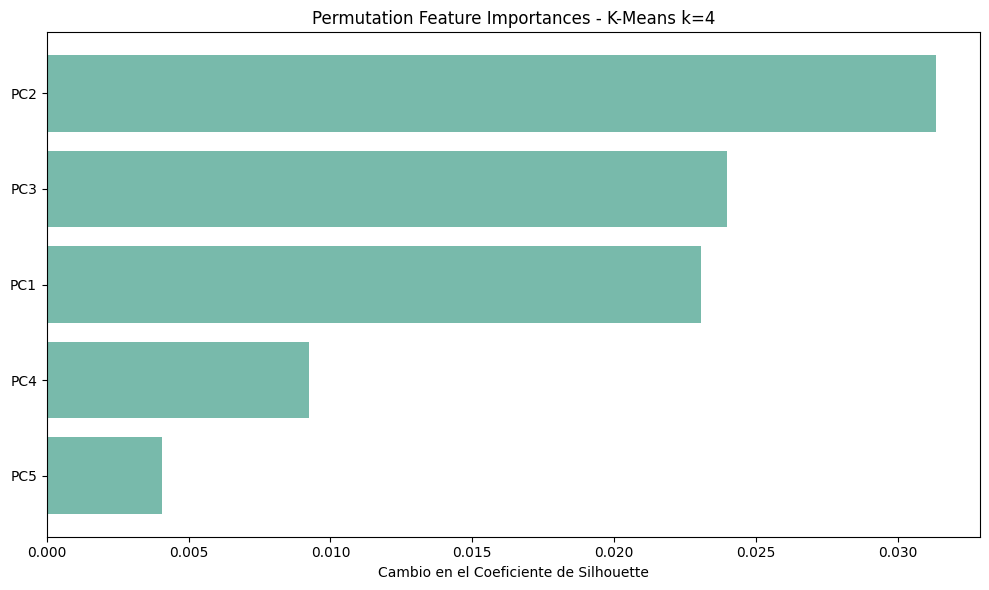

In [29]:
# Extraemos nombres de las features (componentes principales en este caso)
feature_names = X_pca_sample.columns.values

# Ordenación en función de la importancia
sorted_indices_perm = np.argsort(np.abs(p_importance_k4_pca.importances_mean))

# Gráfico de barras para mostrar resultados
plt.figure(figsize=(10, 6))

plt.barh(range(len(feature_names)), p_importance_k4_pca.importances_mean[sorted_indices_perm], color='#69B3A2', alpha=0.9)
plt.yticks(range(len(feature_names)), feature_names[sorted_indices_perm])
plt.title("Permutation Feature Importances - K-Means k=4")
plt.xlabel("Cambio en el Coeficiente de Silhouette")

plt.tight_layout()
plt.show()

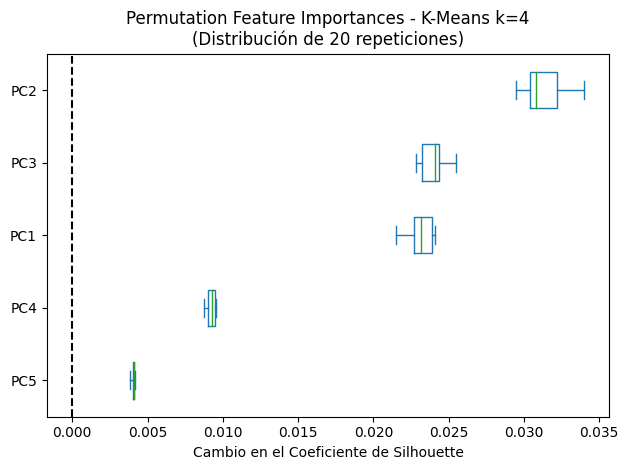

In [30]:
# Boxplot de las importancias de permutación (muestra la distribución de las 20 repeticiones)
# Ordenamos variables en función de su importancia media
sorted_importances_idx = p_importance_k4_pca.importances_mean.argsort()
# Generamos un nuevo df cib todas las repeticiones
importances = pd.DataFrame(
    p_importance_k4_pca.importances[sorted_importances_idx].T,
    columns=feature_names[sorted_importances_idx],
)
# Construimos boxplot de la distribución de importancias de cada variable
ax = importances.plot.box(vert=False, whis=10)
ax.set_title("Permutation Feature Importances - K-Means k=4\n(Distribución de 20 repeticiones)")
ax.axvline(x=0, color="k", linestyle="--")
ax.set_xlabel("Cambio en el Coeficiente de Silhouette")
ax.figure.tight_layout()
plt.show()

### 4.1.3 Cálculo de la importancia de variables para K-Means k=7



In [31]:
# Permutation Feature Importance para K-Means k=7 (sobre muestra PCA)
# Si existe el resultado guardado, lo cargamos; si no, lo calculamos
import os
if os.path.exists('resultados_explicabilidad/p_importance_k7_pca.pkl'):
    p_importance_k7_pca = joblib.load('resultados_explicabilidad/p_importance_k7_pca.pkl')
else:
    # Convertimos a array numpy para evitar warnings (el modelo fue entrenado sin feature names)
    p_importance_k7_pca = permutation_importance(
        kmeans_k7_pca,
        X_pca_sample.values,
        y=None,
        n_repeats=20,
        random_state=42,
        scoring=cluster_silhouette_score
    )

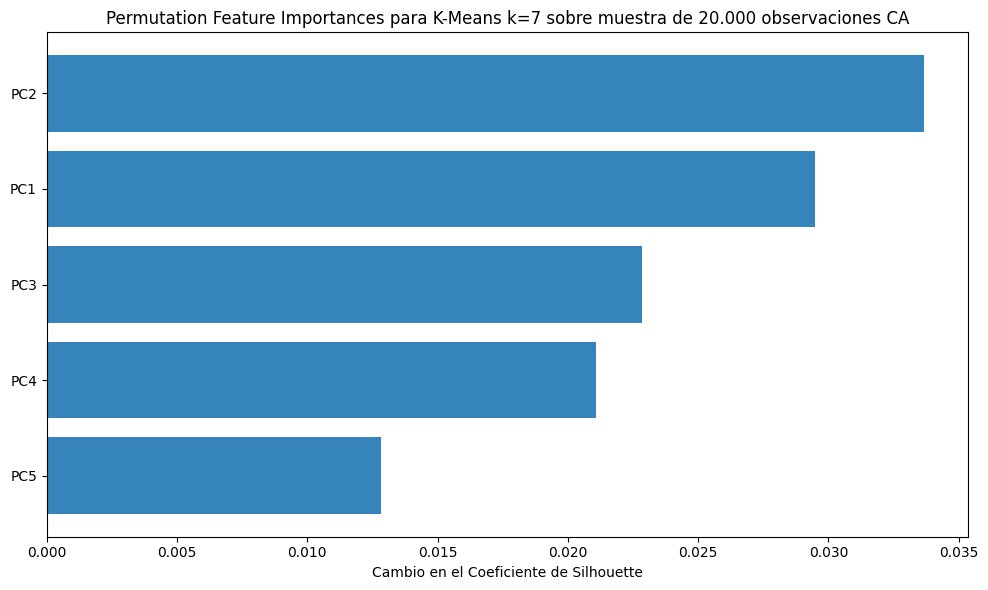

In [32]:
# Nombres de las features (componentes principales)
feature_names_k7 = X_pca_sample.columns.values

# Ordenación de menor a mayor importancia (la menos importante arriba, la más importante abajo)
sorted_indices_perm_k7 = np.argsort(np.abs(p_importance_k7_pca.importances_mean))

# Visualizamos con los atributos ordenados de menor a mayor importancia
plt.figure(figsize=(10, 6))

plt.barh(range(len(feature_names_k7)), p_importance_k7_pca.importances_mean[sorted_indices_perm_k7], alpha=0.9)
plt.yticks(range(len(feature_names_k7)), feature_names_k7[sorted_indices_perm_k7])
plt.title("Permutation Feature Importances para K-Means k=7 sobre muestra de 20.000 observaciones CA")
plt.xlabel("Cambio en el Coeficiente de Silhouette")

plt.tight_layout()
plt.show()

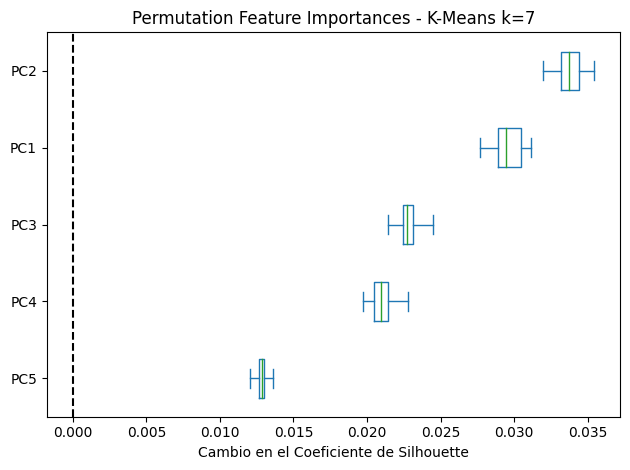

In [33]:
# Boxplot de las importancias de permutación (muestra la distribución de las 20 repeticiones)
# Ordenamos variables en función de su importancia media
sorted_importances_idx_k7 = p_importance_k7_pca.importances_mean.argsort()
# Generamos un nuevo DataFrame con todas las repeticiones
importances_k7 = pd.DataFrame(
    p_importance_k7_pca.importances[sorted_importances_idx_k7].T,
    columns=feature_names_k7[sorted_importances_idx_k7],
)
# Construimos el boxplot de la distribución de importancias de cada componente principal
ax = importances_k7.plot.box(vert=False, whis=10)
ax.set_title("Permutation Feature Importances - K-Means k=7")
ax.axvline(x=0, color="k", linestyle="--")
ax.set_xlabel("Cambio en el Coeficiente de Silhouette")
ax.figure.tight_layout()
plt.show()

### 4.1.4 Cálculo de la importancia de variables para K-Means k=7 sobre el conjunto estandarizado

In [34]:
# Muestra representativa para acelerar el cálculo
df_scaled_sample = df_scaled.sample(n=20000, random_state=42)

# Permutation Feature Importance para K-Means k=7 sobre datos estandarizados (sin PCA)
# Si existe el resultado guardado, lo cargamos; si no, lo calculamos
import os
if os.path.exists('resultados_explicabilidad/p_importance_k7_estand.pkl'):
    p_importance_k7_estand = joblib.load('resultados_explicabilidad/p_importance_k7_estand.pkl')
else:
    # Convertimos a array numpy para evitar warnings (el modelo fue entrenado sin feature names)
    p_importance_k7_estand = permutation_importance(
        kmeans_k7_estand,
        df_scaled_sample.values,
        y=None,
        n_repeats=20,
        random_state=42,
        scoring=cluster_silhouette_score
    )

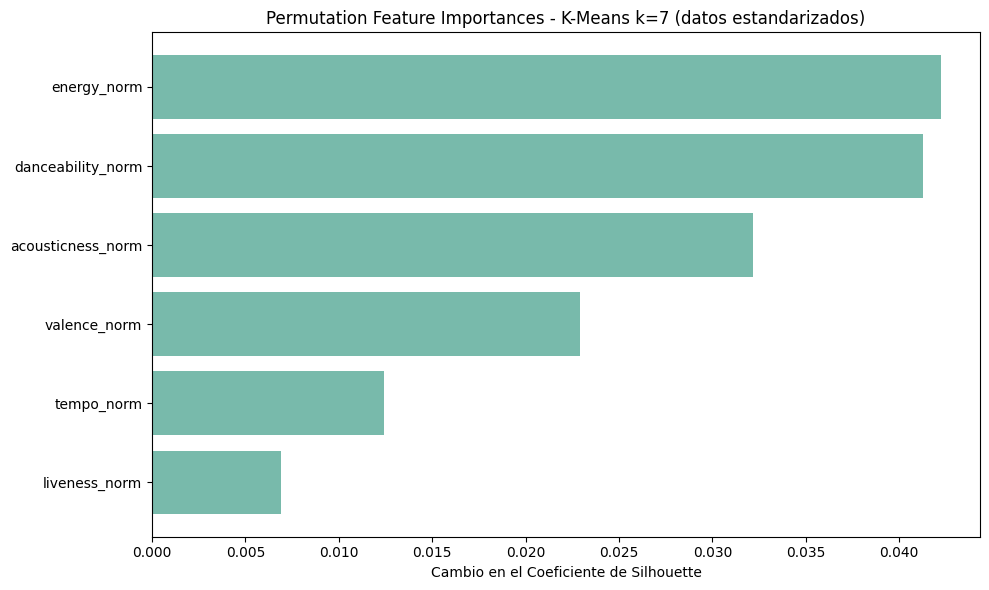

In [35]:
# Nombres de las features (variables estandarizadas)
feature_names_estand = df_scaled_sample.columns.values

# Ordenación de menor a mayor importancia (la menos importante arriba, la más importante abajo)
sorted_indices_perm_estand = np.argsort(np.abs(p_importance_k7_estand.importances_mean))

# Visualizamos con los atributos ordenados de menor a mayor importancia
plt.figure(figsize=(10, 6))

plt.barh(range(len(feature_names_estand)), p_importance_k7_estand.importances_mean[sorted_indices_perm_estand], color='#69B3A2', alpha=0.9)
plt.yticks(range(len(feature_names_estand)), feature_names_estand[sorted_indices_perm_estand])
plt.title("Permutation Feature Importances - K-Means k=7 (datos estandarizados)")
plt.xlabel("Cambio en el Coeficiente de Silhouette")

plt.tight_layout()
plt.show()

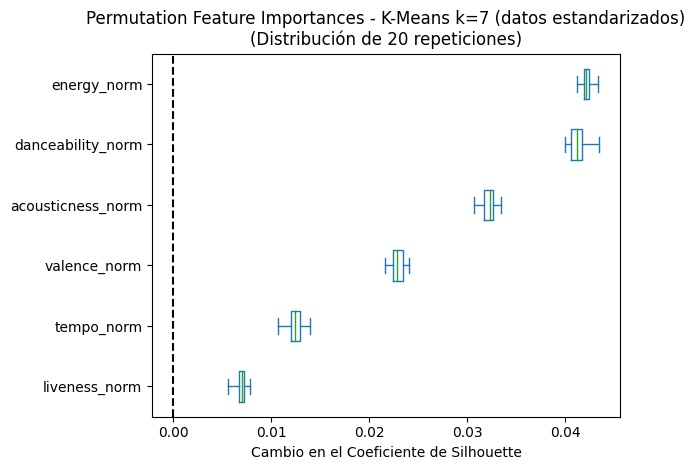

In [36]:
# Boxplot de las importancias de permutación (muestra la distribución de las 20 repeticiones)
# Ordenamos variables en función de su importancia media
sorted_importances_idx_estand = p_importance_k7_estand.importances_mean.argsort()
# Generamos un nuevo DataFrame con todas las repeticiones
importances_estand = pd.DataFrame(
    p_importance_k7_estand.importances[sorted_importances_idx_estand].T,
    columns=feature_names_estand[sorted_importances_idx_estand],
)
# Construimos el boxplot de la distribución de importancias de cada variable estandarizada
ax = importances_estand.plot.box(vert=False, whis=10)
ax.set_title("Permutation Feature Importances - K-Means k=7 (datos estandarizados)\n(Distribución de 20 repeticiones)")
ax.axvline(x=0, color="k", linestyle="--")
ax.set_xlabel("Cambio en el Coeficiente de Silhouette")
ax.figure.tight_layout()
plt.show()

In [37]:
# Guardado de resultados de Permutation Feature Importance
import os
os.makedirs('resultados_explicabilidad', exist_ok=True)

# Guardar solo los resultados de Permutation Feature Importance
joblib.dump(p_importance_k4_pca, 'resultados_explicabilidad/p_importance_k4_pca.pkl')
joblib.dump(p_importance_k7_pca, 'resultados_explicabilidad/p_importance_k7_pca.pkl')
joblib.dump(p_importance_k7_estand, 'resultados_explicabilidad/p_importance_k7_estand.pkl')

print("Resultados de Permutation Feature Importance guardados correctamente")

Resultados de Permutation Feature Importance guardados correctamente


### 4.1.5 Comparación e interpretación de la importancia de variables

TODO AQUI EXPLICACION

## 4.2 SHAP Values para clustering

### Definición de la función de salida para K-Means (distancias a centroides)

### Cálculo de SHAP Values para K-Means k=4

### Cálculo de SHAP Values para GMM n=20

### Visualización e interpretación de SHAP por clúster


Using 20000 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
100%|██████████| 5000/5000 [02:32<00:00, 32.74it/s]


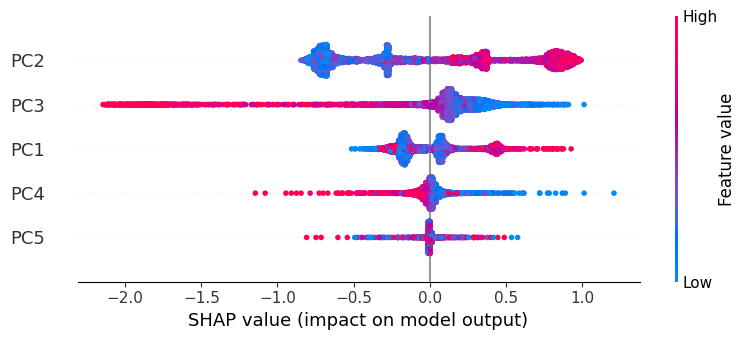

In [38]:
# SHAP Values para K-Means k=4 sobre el espacio PCA

# Seleccionamos una muestra de fondo (background) para el KernelExplainer
# Esta muestra representa la distribución global y reduce el coste computacional
X_pca_background = X_pca_df.sample(n=20000, random_state=42)

# Seleccionamos un subconjunto de observaciones que queremos explicar
X_pca_explain = X_pca_df.sample(n=5000, random_state=24)

# Definimos el explicador SHAP usando la función predict de K-Means k=4
explainer_k4 = shap.KernelExplainer(
    model=kmeans_k4_pca.predict,
    data=X_pca_background.values,
)

# Calculamos los valores SHAP para las observaciones seleccionadas
shap_values_k4 = explainer_k4.shap_values(X_pca_explain.values)

# Visualización: summary plot en el espacio de componentes principales
shap.initjs()
shap.summary_plot(
    shap_values_k4,
    X_pca_explain,
    feature_names=X_pca_explain.columns
)


100%|██████████| 1000/1000 [00:06<00:00, 153.13it/s]


c:\Users\marcf\Desktop\UOC\TFG\PEC2\TFG\venv\lib\site-packages\shap\plots\_beeswarm.py:1150: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
c:\Users\marcf\Desktop\UOC\TFG\PEC2\TFG\venv\lib\site-packages\shap\plots\_beeswarm.py:758: UserWarning: The figure layout has changed to tight
  plt.tight_layout(pad=0, w_pad=0, h_pad=0.0)


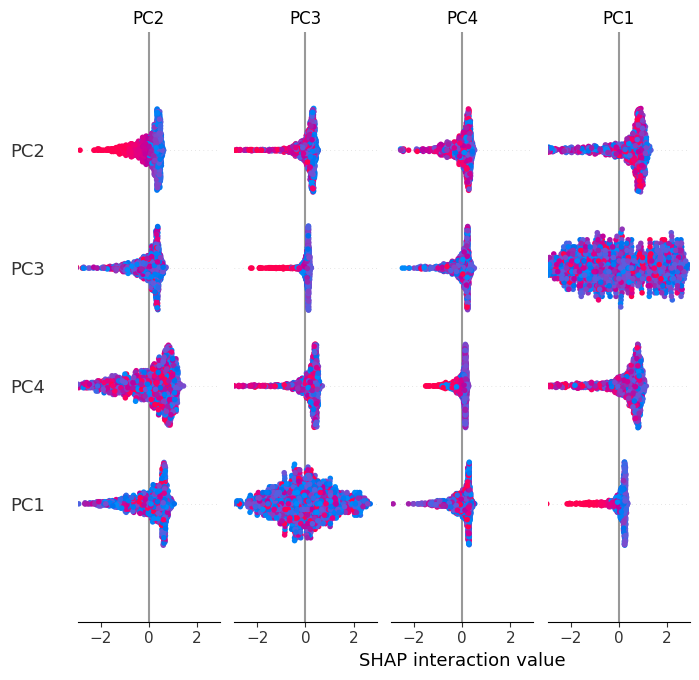

<Figure size 640x480 with 0 Axes>

In [39]:
import shap
import numpy as np
from sklearn.metrics import pairwise_distances

# 1) Background resumido con k-means de SHAP para ir más rápido
X_pca_background = shap.kmeans(X_pca_df, 50)   # 50 puntos resumen

# 2) Subconjunto de observaciones a explicar
X_pca_explain = X_pca_df.sample(n=1000, random_state=24)

# 3) Definimos una función "modelo" continua:
#    devuelve -distancia euclídea a cada centroide (afinidad al clúster)
def kmeans_affinity(X):
    """
    X: array (n_muestras, n_features)
    return: array (n_muestras, n_clusters)
            cada columna es la afinidad (-distancia) a un clúster
    """
    # distancias a cada centroide (n_muestras, n_clusters)
    D = pairwise_distances(X, kmeans_k4_pca.cluster_centers_, metric="euclidean")
    # afinidad = -distancia (cuanto más alto, más cerca del centroide)
    return -D

# 4) Explicador SHAP sobre la función de afinidad a los clústeres
explainer_k4 = shap.KernelExplainer(
    model=kmeans_affinity,
    data=X_pca_background
)

# 5) Cálculo de valores SHAP para las observaciones seleccionadas
#    Esto devuelve una lista de arrays: uno por cada clúster (salida del modelo)
shap_values_k4 = explainer_k4.shap_values(X_pca_explain.values)

# 6) Summary plot para todas las salidas (clústeres) a la vez
shap.initjs()
shap.summary_plot(
    shap_values_k4,
    X_pca_explain,
    feature_names=X_pca_explain.columns
)

plt.tight_layout()

plt.show()